In [5]:
import numpy as np 
import torch, torchvision
import torch.nn as nn 
import torch.optim as optim 
import torch.nn.functional as F
from torch.utils.data import DataLoader 
import torchvision.transforms as transforms 
import matplotlib.pyplot as plt 

In [2]:
torch.manual_seed(20) 

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
    print('cuda available')
else:
    device = 'cpu'
    print('only CPU available')

cuda available


In [4]:
train_batch = 16
test_batch = 16

In [6]:
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor()) 
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor()) 

In [13]:
train_set.data.shape 

torch.Size([60000, 28, 28])

In [17]:
train_set.targets.shape 

torch.Size([60000])

In [19]:
mean = train_set.data.float().mean() 
std = train_set.data.float().std() 

In [21]:
tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean/255.0], std=[std/255.0])
])

In [22]:
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=tform) 

In [23]:
train_loader = DataLoader(train_set, batch_size=train_batch, shuffle=True)
test_loader = DataLoader(test_set, batch_size=test_batch, shuffle=True)

In [24]:
example_data, example_label = next(iter(train_loader)) 

In [26]:
example_data.shape 

torch.Size([64, 1, 28, 28])

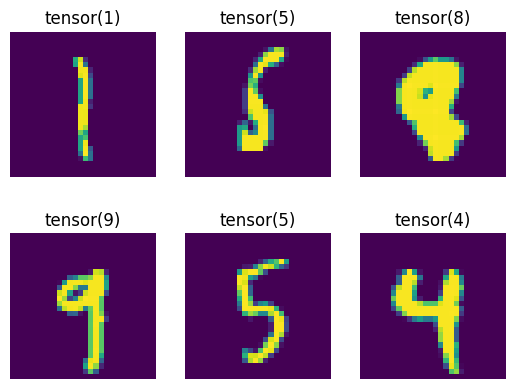

In [27]:
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_data[i].squeeze())
    plt.axis('off')
    plt.title(example_label[i]) 

In [34]:
# building the AE model 
class AutoEncoder(nn.Module):
    def __init__(self, in_features, hidden_dim, out_features, bias=True):
        super().__init__()
        self.encoder = nn.Linear(in_features, hidden_dim)
        self.decoder = nn.Linear(hidden_dim, out_features) 

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x)
        x = self.decoder(x)
        x = F.relu(x)
        return x 

In [35]:
model = AutoEncoder(28*28, 100, 28*28)
model = model.to(device)
model 

AutoEncoder(
  (encoder): Linear(in_features=784, out_features=100, bias=True)
  (decoder): Linear(in_features=100, out_features=784, bias=True)
)

In [37]:
# before training, the reconstruction should be noise 
example_data = example_data.to(device) 
logits = model(example_data.view(example_data.shape[0], -1))
example_recon = logits.cpu().detach().view(logits.shape[0], 28, 28) 

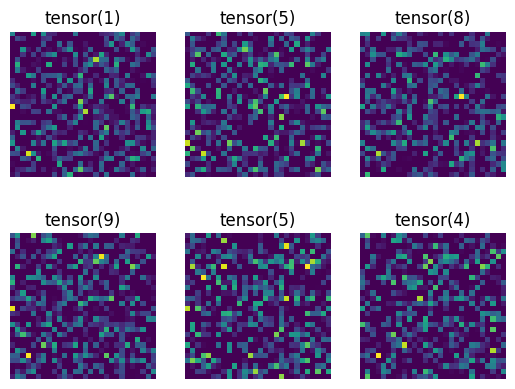

In [38]:
# visualizing reconstruction before training the AE
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_recon[i])
    plt.title(example_label[i])
    plt.axis('off')

In [39]:
learning_rate = 1e-3
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)
loss_fn = F.mse_loss

In [40]:
train_loss = [] 
test_loss = [] 

In [41]:
def train():
    model.train()

    running_loss = 0 

    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        logits = model(data.view(data.shape[0], -1))
        loss = loss_fn(logits, data.view(data.shape[0], -1))

        running_loss += loss.item()

        optimizer.zero_grad() 
        loss.backward() 
        optimizer.step() 

    train_loss.append(running_loss / len(train_set))

In [42]:
def test():
    model.eval()

    running_loss = 0 

    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.to(device)

            logits = model(data.view(data.shape[0], -1))
            loss = loss_fn(logits, data.view(data.shape[0], -1))

            running_loss += loss.item() 

        test_loss.append(running_loss / len(test_set))

In [ ]:
# let's train the model 
n_epochs = 500 
for i in range(n_epochs):
    train()
    test() 
    if np.mod(i, 10) == 0:
        print(f'epoch {i}, train loss: {train_loss[-1]}, test loss: {test_loss[-1]}')

epoch 0, train loss: 0.015774242035547892, test loss: 0.01591816126704216
epoch 10, train loss: 0.013024886909127235, test loss: 0.013042614167928696
epoch 20, train loss: 0.011854822866121929, test loss: 0.011888204503059387
epoch 30, train loss: 0.01121290390988191, test loss: 0.011231661593914031
epoch 40, train loss: 0.010444112264116606, test loss: 0.010439112216234208
epoch 50, train loss: 0.00981658734381199, test loss: 0.009799700504541396
epoch 60, train loss: 0.009290644857287407, test loss: 0.009274544632434845
epoch 70, train loss: 0.00883957864244779, test loss: 0.008818818193674088
epoch 80, train loss: 0.008458595942954223, test loss: 0.008431646111607552


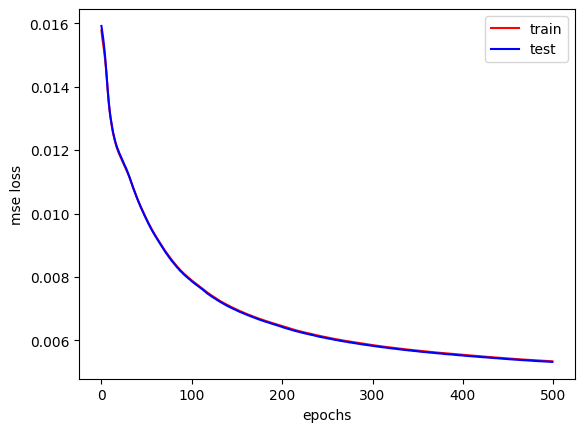

In [47]:
plt.figure()
plt.plot(train_loss, linestyle='-', color='r', label='train')
plt.plot(test_loss, linestyle='-', color='blue', label='test')
plt.xlabel('epochs')
plt.ylabel('mse loss')
plt.legend() 

In [48]:
# after learning, the reconstruction should make sense
logits = model(example_data.view(example_data.shape[0], -1))
example_output = logits.cpu().detach().view(logits.shape[0], 28, 28) 

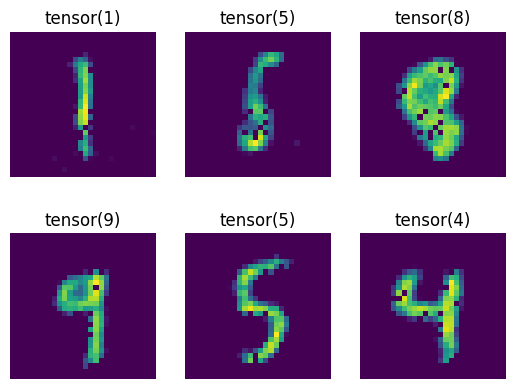

In [49]:
plt.figure()
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(example_output[i])
    plt.title(example_label[i])
    plt.axis('off')